#ЛР 1

## Импорты

In [1]:
!pip install numpy matplotlib scikit-learn

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Сигмоидная функция активации и её производная

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

## Нейронная сеть

In [4]:
class Layer:
    def __init__(self, input_dim, output_dim):
        self.W = np.random.randn(input_dim, output_dim) * 0.1
        self.b = np.zeros((1, output_dim))
        self.A_prev = None
        self.Z = None
        self.A = None
        self.dW = None
        self.db = None

    def forward(self, A_prev):
        self.A_prev = A_prev
        self.Z = A_prev @ self.W + self.b
        self.A = sigmoid(self.Z)
        return self.A

    def backward(self, dZ):
        m = self.A_prev.shape[0]
        self.dW = self.A_prev.T @ dZ / m
        self.db = np.sum(dZ, axis=0, keepdims=True) / m
        dA_prev = dZ @ self.W.T
        return dA_prev

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

In [5]:
class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def backward(self, y_true):
        dZ = self.layers[-1].A - y_true
        dA = self.layers[-1].backward(dZ)
        for i in range(len(self.layers) - 2, -1, -1):
            dZ = dA * sigmoid_derivative(self.layers[i].Z)
            dA = self.layers[i].backward(dZ)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)

    def train(self, X, y, epochs, lr, verbose=True):
        y = y.reshape(-1, 1)
        for epoch in range(epochs):
            A = self.forward(X)
            loss = -np.mean(y * np.log(A + 1e-8) + (1 - y) * np.log(1 - A + 1e-8))
            self.backward(y)
            self.update(lr)
            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")

    def predict(self, X):
        A = self.forward(X)
        return (A > 0.5).astype(int).flatten()

## Загрузка и подготовка данных

In [6]:
iris = load_iris()
X = iris.data
y = iris.target

mask = (y == 1) | (y == 2)
X = X[mask]
y = y[mask]
y = y - 1

X = X[:, [2, 3]]

mean = X.mean(axis=0)
std = X.std(axis=0)
X = (X - mean) / std

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

## Обучение одного нейрона

In [7]:
nn_single = NeuralNetwork([Layer(2, 1)])
nn_single.train(X_train, y_train, epochs=1000, lr=0.1, verbose=True)

Epoch 0, Loss: 0.6295
Epoch 100, Loss: 0.1693
Epoch 200, Loss: 0.1289
Epoch 300, Loss: 0.1126
Epoch 400, Loss: 0.1036
Epoch 500, Loss: 0.0979
Epoch 600, Loss: 0.0940
Epoch 700, Loss: 0.0911
Epoch 800, Loss: 0.0889
Epoch 900, Loss: 0.0872


Single Neuron Metrics:
Accuracy: 0.9000, Precision: 0.9167, Recall: 0.8462, F1: 0.8800


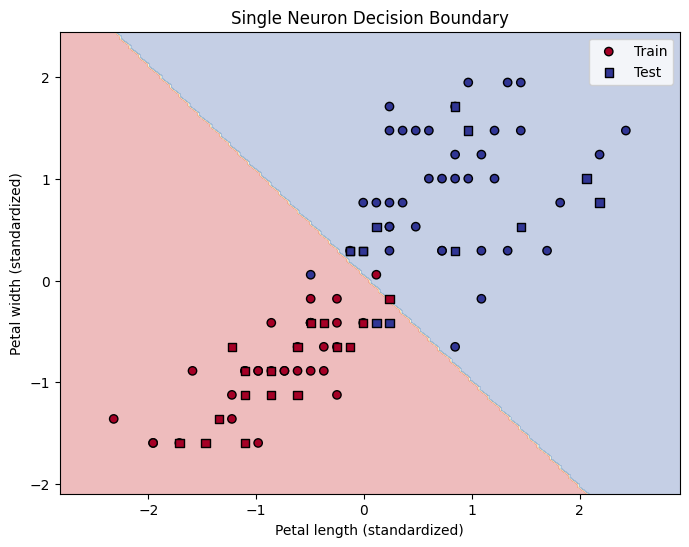

In [8]:
y_pred_single = nn_single.predict(X_test)
acc_s = accuracy_score(y_test, y_pred_single)
prec_s = precision_score(y_test, y_pred_single)
rec_s = recall_score(y_test, y_pred_single)
f1_s = f1_score(y_test, y_pred_single)
print("Single Neuron Metrics:")
print(f"Accuracy: {acc_s:.4f}, Precision: {prec_s:.4f}, Recall: {rec_s:.4f}, F1: {f1_s:.4f}")

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn_single.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), edgecolors='k', cmap=plt.cm.RdYlBu, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.flatten(), marker='s', edgecolors='k', cmap=plt.cm.RdYlBu, label='Test')
plt.title('Single Neuron Decision Boundary')
plt.xlabel('Petal length (standardized)')
plt.ylabel('Petal width (standardized)')
plt.legend()
plt.show()

## Обучение двухслойной сети

In [10]:
nn_two = NeuralNetwork([Layer(2, 10), Layer(10, 1)])
nn_two.train(X_train, y_train, epochs=2000, lr=0.1, verbose=True)

Epoch 0, Loss: 0.6959
Epoch 100, Loss: 0.5968
Epoch 200, Loss: 0.3341
Epoch 300, Loss: 0.1940
Epoch 400, Loss: 0.1418
Epoch 500, Loss: 0.1182
Epoch 600, Loss: 0.1055
Epoch 700, Loss: 0.0980
Epoch 800, Loss: 0.0931
Epoch 900, Loss: 0.0898
Epoch 1000, Loss: 0.0874
Epoch 1100, Loss: 0.0857
Epoch 1200, Loss: 0.0844
Epoch 1300, Loss: 0.0834
Epoch 1400, Loss: 0.0827
Epoch 1500, Loss: 0.0821
Epoch 1600, Loss: 0.0816
Epoch 1700, Loss: 0.0811
Epoch 1800, Loss: 0.0808
Epoch 1900, Loss: 0.0805


Two-Layer Network Metrics:
Accuracy: 0.9000, Precision: 0.9167, Recall: 0.8462, F1: 0.8800


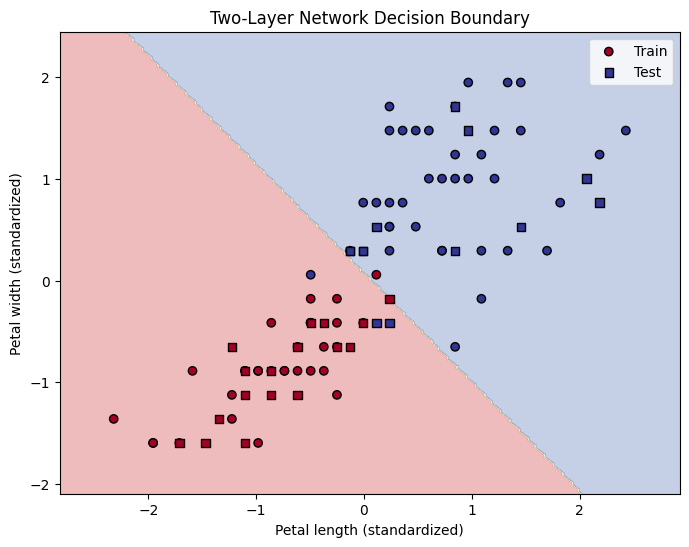

In [11]:
y_pred_two = nn_two.predict(X_test)
acc_t = accuracy_score(y_test, y_pred_two)
prec_t = precision_score(y_test, y_pred_two)
rec_t = recall_score(y_test, y_pred_two)
f1_t = f1_score(y_test, y_pred_two)
print("Two-Layer Network Metrics:")
print(f"Accuracy: {acc_t:.4f}, Precision: {prec_t:.4f}, Recall: {rec_t:.4f}, F1: {f1_t:.4f}")

Z2 = nn_two.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z2, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), edgecolors='k', cmap=plt.cm.RdYlBu, label='Train')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test.flatten(), marker='s', edgecolors='k', cmap=plt.cm.RdYlBu, label='Test')
plt.title('Two-Layer Network Decision Boundary')
plt.xlabel('Petal length (standardized)')
plt.ylabel('Petal width (standardized)')
plt.legend()
plt.show()

## Сравнение метрик двух моделей

In [12]:
print("\nComparison of Models:")
print(f"{'Model':<20} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-score':<10}")
print(f"{'Single Neuron':<20} {acc_s:<10.4f} {prec_s:<10.4f} {rec_s:<10.4f} {f1_s:<10.4f}")
print(f"{'Two-Layer NN':<20} {acc_t:<10.4f} {prec_t:<10.4f} {rec_t:<10.4f} {f1_t:<10.4f}")


Comparison of Models:
Model                Accuracy   Precision  Recall     F1-score  
Single Neuron        0.9000     0.9167     0.8462     0.8800    
Two-Layer NN         0.9000     0.9167     0.8462     0.8800    
